# Privilege Escalation Risk Classification Using Machine Learning

**Model:** Random Forest Classifier  
**Dataset:** Linux & Windows Privilege Escalation Dataset  
**Framework:** Python, pandas, scikit-learn  
**Task:** Multiclass classification of severity (Low, Medium, High, Critical)

This notebook implements the project proposal's preprocessing and initial model-development workflow. The commands in the dataset are treated strictly as text; they are never executed.

## 1. Setup

If using Google Colab, upload `priv_escalation_dataset.csv` to the session before running the data-loading cell. The notebook is also runnable locally when the CSV is in the same folder.

In [1]:
# Colab upload helper
from pathlib import Path

DATA_PATH = Path("priv_escalation_dataset.csv")

if not DATA_PATH.exists():
    from google.colab import files
    uploaded = files.upload()
    if "priv_escalation_dataset.csv" not in uploaded:
        raise FileNotFoundError("Please upload priv_escalation_dataset.csv")

print(f"Dataset path: {DATA_PATH}")

Dataset path: priv_escalation_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (2597, 8)


,id,platform,command,description,category,severity,mapped_technique,reference
0,1,Linux,7z a -ttar -an -so /path/to/input-file | 7z e ...,Abuse the '7z' binary (file read) in a sudo co...,Sudo Misconfiguration,Medium,T1548.003,https://gtfobins.github.io/gtfobins/7z/
1,2,Linux,7z a -ttar -an -so /path/to/input-file | 7z e ...,Abuse the '7z' binary (file read) in a unprivi...,Arbitrary File Read,Low,T1552,https://gtfobins.github.io/gtfobins/7z/
2,3,Linux,"R --no-save -e 'system(""/bin/sh"")'",Abuse the 'R' binary (shell) in a sudo context...,Sudo Misconfiguration,Critical,T1548.003,https://gtfobins.github.io/gtfobins/R/
3,4,Linux,"R --no-save -e 'system(""/bin/sh"")'",Abuse the 'R' binary (shell) in a suid context...,SUID Binaries,Critical,T1548.001,https://gtfobins.github.io/gtfobins/R/
4,5,Linux,"R --no-save -e 'system(""/bin/sh"")'",Abuse the 'R' binary (shell) in a unprivileged...,Shell Escape,High,T1548,https://gtfobins.github.io/gtfobins/R/


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2597 entries, 0 to 2596
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                2597 non-null   int64 
 1   platform          2597 non-null   object
 2   command           2597 non-null   object
 3   description       2597 non-null   object
 4   category          2597 non-null   object
 5   severity          2597 non-null   object
 6   mapped_technique  2597 non-null   object
 7   reference         2597 non-null   object
dtypes: int64(1), object(7)
memory usage: 162.4+ KB


## 2. Data Cleaning and Dataset Inspection

The original dataset contains 2,597 records and eight columns. The cleaning stage checks for missing values, exact duplicate rows, unexpected severity labels, and whitespace in text fields. No commands are executed during this process.

In [3]:
# Inspect missing values and duplicates
print("Missing values:")
display(df.isna().sum().to_frame("missing"))

print("Exact duplicate rows:", df.duplicated().sum())

print("\nSeverity distribution:")
display(df["severity"].value_counts(dropna=False))

print("\nUnique platform values:", df["platform"].unique())
print("Number of categories:", df["category"].nunique())
print("Number of unique commands:", df["command"].nunique())
print("Number of unique descriptions:", df["description"].nunique())

Missing values:


,missing
id,0
platform,0
command,0
description,0
category,0
severity,0
mapped_technique,0
reference,0


Exact duplicate rows: 0

Severity distribution:


severity
Critical    853
Medium      849
High        571
Low         324
Name: count, dtype: int64


Unique platform values: ['Linux' 'Windows']
Number of categories: 28
Number of unique commands: 1363
Number of unique descriptions: 2405


In [4]:
# Create a cleaned copy
clean_df = df.drop_duplicates().copy()

text_columns = [
    "platform", "command", "description", "category",
    "severity", "mapped_technique", "reference"
]

for column in text_columns:
    clean_df[column] = clean_df[column].fillna("").astype(str).str.strip()

expected_severity = {"Low", "Medium", "High", "Critical"}
clean_df = clean_df[clean_df["severity"].isin(expected_severity)].copy()

print("Cleaned dataset shape:", clean_df.shape)
print("Remaining missing values:", int(clean_df.isna().sum().sum()))
print("Remaining duplicate rows:", int(clean_df.duplicated().sum()))

Cleaned dataset shape: (2597, 8)
Remaining missing values: 0
Remaining duplicate rows: 0


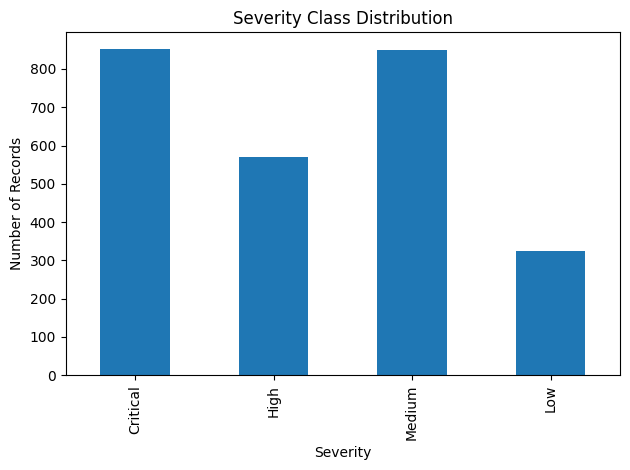

In [5]:
# Visualize the target distribution
severity_order = ["Critical", "High", "Medium", "Low"]

clean_df["severity"].value_counts().reindex(severity_order).plot(
    kind="bar",
    title="Severity Class Distribution",
    xlabel="Severity",
    ylabel="Number of Records"
)
plt.tight_layout()
plt.show()

## 3. Feature Selection and Feature Engineering

### Excluded fields
- `id`: identifier rather than a predictive characteristic.
- `reference`: contains direct external URLs and may cause the model to learn source-specific patterns.
- `mapped_technique`: a direct MITRE ATT&CK technique mapping; it is excluded from the initial model to reduce the risk of learning a near-direct association between technique and severity.

### Retained fields
- `platform`
- `category`
- `command`
- `description`

### Engineered fields
The command and description are combined into one text feature. Three numerical text-derived features are also created:
1. command character length
2. description character length
3. combined text word count

In [6]:
# Feature engineering
clean_df["text"] = (
    clean_df["command"] + " " + clean_df["description"]
).str.strip()

clean_df["command_len"] = clean_df["command"].str.len()
clean_df["description_len"] = clean_df["description"].str.len()
clean_df["text_word_count"] = clean_df["text"].str.split().str.len()

feature_columns = [
    "platform",
    "category",
    "text",
    "command_len",
    "description_len",
    "text_word_count"
]

X = clean_df[feature_columns]
y = clean_df["severity"]

display(X.head())
print("Feature matrix before transformation:", X.shape)

,platform,category,text,command_len,description_len,text_word_count
0,Linux,Sudo Misconfiguration,7z a -ttar -an -so /path/to/input-file | 7z e ...,59,104,29
1,Linux,Arbitrary File Read,7z a -ttar -an -so /path/to/input-file | 7z e ...,59,112,29
2,Linux,Sudo Misconfiguration,"R --no-save -e 'system(""/bin/sh"")' Abuse the '...",34,99,20
3,Linux,SUID Binaries,"R --no-save -e 'system(""/bin/sh"")' Abuse the '...",34,99,20
4,Linux,Shell Escape,"R --no-save -e 'system(""/bin/sh"")' Abuse the '...",34,107,20


Feature matrix before transformation: (2597, 6)


## 4. Train-Test Split

An 80/20 stratified split is used. Stratification helps preserve the distribution of the four severity classes in the training and testing subsets. `random_state=42` makes the split reproducible.

The preprocessing objects are fitted only through the training pipeline and then applied to the test set.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining class distribution:")
display(y_train.value_counts().reindex(severity_order))

print("\nTesting class distribution:")
display(y_test.value_counts().reindex(severity_order))

Training records: 2077
Testing records: 520

Training class distribution:


severity
Critical    682
High        457
Medium      679
Low         259
Name: count, dtype: int64


Testing class distribution:


severity
Critical    171
High        114
Medium      170
Low          65
Name: count, dtype: int64

## 5. Data Transformation Pipeline

The model uses a `ColumnTransformer`:

- `OneHotEncoder` converts `platform` and `category` into numerical indicator features.
- `TfidfVectorizer` converts the combined command/description text into numerical text features using unigrams and bigrams.
- The engineered numerical features are passed through unchanged.

The entire preprocessing stage is placed inside a scikit-learn `Pipeline` so that the test set does not influence the learned transformations.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ["platform", "category"]
        ),
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=5000
            ),
            "text"
        ),
        (
            "numeric",
            "passthrough",
            ["command_len", "description_len", "text_word_count"]
        )
    ]
)

print("Preprocessor configured.")

Preprocessor configured.


## 6. Random Forest Model

The initial model configuration uses:

- 300 decision trees
- `class_weight="balanced"` to account for unequal class frequencies
- `random_state=42` for reproducibility
- `n_jobs=-1` to use available CPU cores

This is the initial development configuration; later iterations can tune hyperparameters using validation data without fitting to the test set.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 7. Evaluation

The held-out test set is used for the final evaluation of this initial configuration. The project reports:

- Accuracy
- Precision
- Recall
- Macro F1-score
- Per-class classification report
- Confusion matrix

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1-score:  {macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=severity_order,
        zero_division=0
    )
)

Accuracy:        0.9788
Macro Precision: 0.9787
Macro Recall:    0.9824
Macro F1-score:  0.9805

Classification Report:
              precision    recall  f1-score   support

    Critical       0.98      0.99      0.99       171
        High       0.97      0.98      0.97       114
      Medium       0.98      0.95      0.97       170
         Low       0.98      1.00      0.99        65

    accuracy                           0.98       520
   macro avg       0.98      0.98      0.98       520
weighted avg       0.98      0.98      0.98       520



,Predicted Critical,Predicted High,Predicted Medium,Predicted Low
Actual Critical,170,0,1,0
Actual High,0,112,2,0
Actual Medium,3,4,162,1
Actual Low,0,0,0,65


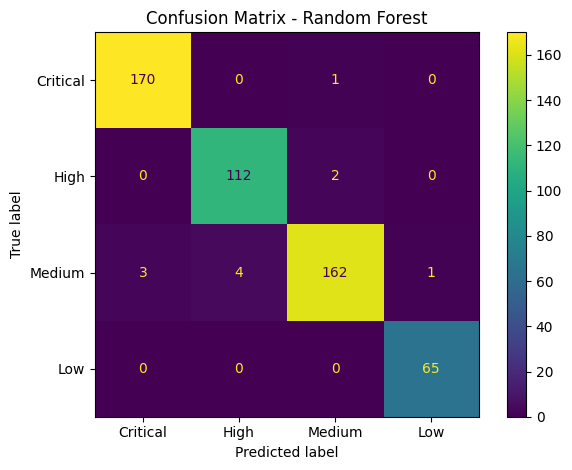

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=severity_order
)

display(
    pd.DataFrame(
        cm,
        index=[f"Actual {x}" for x in severity_order],
        columns=[f"Predicted {x}" for x in severity_order]
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=severity_order
).plot()

plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

## 8. Feature Importance

Random Forest provides feature-importance values after preprocessing. The next cell maps the transformed feature names back to their importance scores so the most influential model inputs can be inspected.

Because text features are transformed into many TF-IDF columns, individual words or n-grams may appear among the most important features.

,feature,importance
4672,text__unprivileged context,0.045322
1987,text__in unprivileged,0.041763
4671,text__unprivileged,0.038799
5031,numeric__description_len,0.020695
5,categorical__category_Arbitrary File Read,0.019499
3639,text__shell in,0.018383
25,categorical__category_Shell Escape,0.017389
1638,text__file read,0.017092
3896,text__sudo context,0.016123
17,categorical__category_Execute,0.015914


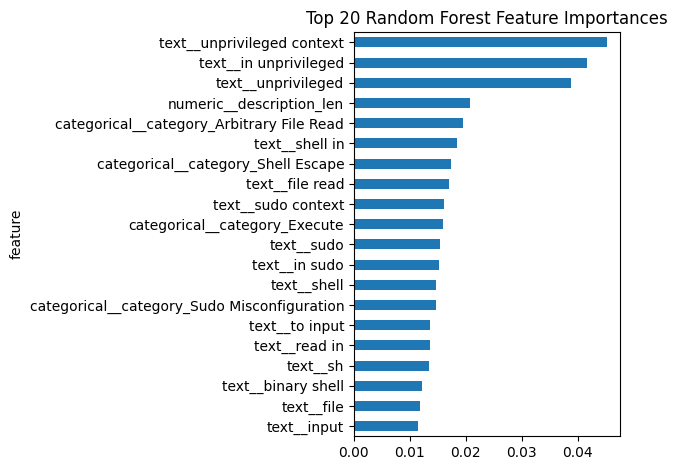

In [12]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

display(importance_df)

importance_df.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    title="Top 20 Random Forest Feature Importances",
    legend=False
)
plt.tight_layout()
plt.show()

## 9. Initial Findings

For the supplied dataset and the fixed 80/20 stratified split, the initial Random Forest configuration is expected to reproduce the development result below when the notebook is run with the same preprocessing and random state:

- **Accuracy:** approximately 97.88%
- **Macro Precision:** approximately 97.87%
- **Macro Recall:** approximately 98.24%
- **Macro F1-score:** approximately 98.05%

These results are preliminary. They describe performance on this held-out split and should not be interpreted as proof that the model will achieve the same performance on new datasets. Future work can include validation-based hyperparameter tuning, additional error analysis, and testing on a separate external dataset.

## 10. Safety Note

This notebook performs defensive cybersecurity analytics only. Dataset commands are loaded and processed as text. No command, script, shell instruction, or privilege-escalation technique from the dataset is executed by the notebook.